In [1]:
import numpy as np
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import traceback

from pathlib import Path
from IPython.display import clear_output
from seppy.util import resample_df
from solo_epd_loader import epd_load
from matplotlib.colors import LogNorm
from scipy.ndimage import vectorized_filter

from aipad.pad_imputation import (
    convert_to_bool_coverage, load_wind_event, coverage_overlap, 
    load_random_file, pad_histogram, induce_missingness
)

from aipad.spacecrafts import SoloConstants, WindConstants
from aipad.datahandler import WindDataHandler

solo = SoloConstants()
wind = WindConstants()

### Generate coverages

In [2]:
import logging
filehandler = logging.FileHandler(filename="./logs/solo_cov.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

bins = 8
time_avg_min = 1
data_path = Path("./data/datafiles")
save_path = Path(f"./data/coverages/{time_avg_min}min_{bins}bins")

data_path.mkdir(exist_ok=True)
save_path.mkdir(exist_ok=True)

max_days = (solo.mission_end - solo.mission_start).days
name = solo.name

try:
    start = int(sys.argv[1])
except (IndexError, ValueError):
    start = 0

logging.info(f"Run start: {start}")

for i in range(start, max_days):
    logging.info(f"Day {i}")
    
    date = solo.mission_start + dt.timedelta(days=i)
    logging.info(f"Forming {name} coverages from date {date}")
    try:
        df, df_rtn, df_hci, energies_dict, metadata_dict = epd_load("ept", startdate=date, 
                                                                    level="l3", autodownload=True,
                                                                    path=str(data_path), pos_timestamp="start")
        
        if (len(df.index) // 60) < 12:
            logging.info(f"Day {i}: Data file not long enough to generate 12 hour coverage, skipping...")
            continue
        
        # if more than 20 % of data is missing, skip
        if np.mean(np.isnan(df.to_numpy())) > 0.20:
            logging.info(f"Day {i}: Over 20 % of the data is missing, skipping...")
            continue
        
        if time_avg_min > 1:
            df = resample_df(df, resample=str(time_avg_min) + "min", pos_timestamp="start")
        elif time_avg_min == 1:
            pass
        else:
            raise ValueError("SolO cadence is 1min, unwise to average less!")
        
        ind = pd.MultiIndex.from_product([solo.sectors, ["min", "center", "max"]])
        df_cov = pd.DataFrame(index=df.index, columns=ind)

        for direction, pa_col, pa_sigma_col in zip(solo.sectors, solo.pitch_angle_mu_columns, 
                                                    solo.pitch_angle_sigma_columns):
            df_cov[(direction, "center")] = df[pa_col]
            df_cov[(direction, "min")] = df[pa_col] - df[pa_sigma_col]
            df_cov[(direction, "max")] = df[pa_col] + df[pa_sigma_col]

        break
        X1, Y1, solo_cov = convert_to_bool_coverage(df_cov, sc=solo, bins=bins)

        # Generate 2 random 12 hour coverages
        
        for j in range(1, 3):
            random_start = np.random.randint(0, len(solo_cov) - 12*60//time_avg_min)
            start_dt = (date+dt.timedelta(minutes=random_start*time_avg_min))
            cov = solo_cov[random_start:random_start+12*60//time_avg_min]
            logging.info(f"Generated 12 hr coverage with shape {cov.shape}")
            np.save(save_path / f"solo_{start_dt.strftime("%Y%m%d_%H%M%S")}_{time_avg_min}min_{bins}bins", cov)

    except UnboundLocalError:
        logging.info(f"No data was found, skipping...")

    clear_output()

03/03/2026 12:12:32 Run start: 0
03/03/2026 12:12:32 Day 0
03/03/2026 12:12:32 Forming SolO coverages from date 2021-01-01 00:00:00


### Generate full and reduced intensity histograms, save intensity data

In [6]:
import logging
import sys
filehandler = logging.FileHandler(filename="./logs/histogram_forming.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

year = 2013

energy_channel = 3
bins = 8
time_avg_min = 1

data_path = Path("./data/datafiles")
#cov_path = Path("./data/coverages") / f"{time_avg_min}min_1deg"
event_path = Path("./data/event_lists")

save_path = Path("./data/intensities")
save_path.mkdir(exist_ok=True)

fname = f"wind_{time_avg_min}min_{bins}bins.h5"

try:
    df = pd.read_csv(event_path / f"wind_events_{year}.csv", delimiter=",")

    for index, data in df.iterrows():
        #solo_cov_bool = load_random_file(cov_path)
        
        onset_dt = pd.to_datetime(data["onset_date"]) + pd.to_timedelta(data["onset_time"])
        # if onset_dt < dt.datetime(2012, 8, 2):  # TODO: "saving" progress
        #     continue
        start = onset_dt - pd.Timedelta(hours=2)
        end = onset_dt + pd.Timedelta(hours=10)

        wind_event = load_wind_event(str(data_path), "Wind 3DP", start, end, "e", channels=energy_channel, averaging=f"{time_avg_min}min")
        wind_cov = wind_event.coverage
        
        wind_event.I_data = vectorized_filter(wind_event.I_data, np.median, size=(3,), axes=(0,))
        
        # X, Y, wind_cov_bool = convert_to_bool_coverage(wind_cov, wind, bins=8)

        # #cov_arr, reshaped = coverage_overlap(solo_cov_bool, wind_cov_bool)
        # # TODO: for now, just skip if there's a shape mismatch. Need to think this through
        # try:
        #     assert solo_cov_bool.shape == wind_cov_bool.shape
        # except AssertionError:
        #     clear_output()
        #     logging.info(f"Coverage shape mismatch: SolO {solo_cov_bool.shape}, Wind {wind_cov_bool.shape} ({onset_dt})")
        #     continue

        # cov_arr = solo_cov_bool & wind_cov_bool
        
        arrays = {}
        X, Y, hist = pad_histogram(wind, wind_event.I_data, wind_cov, bins)
        X, Y, hist_180 = pad_histogram(wind, wind_event.I_data, wind_cov, 180)
        for p in [0.1, 0.2, 0.3, 0.4, 0.5]:
            reduced_cov, mask = induce_missingness(wind_cov, p)
            X, Y, reduced_hist = pad_histogram(wind, wind_event.I_data, reduced_cov, bins)
            arrays[f"reduced_{p:.1f}"] = reduced_hist
            arrays[f"reduced_{p:.1f}_mask"] = mask
        
        arrays["full"] = hist
        arrays["intensities"] = wind_event.I_data
        arrays["times"] = np.datetime_as_string(wind_event.I_times).tolist()
        gname = onset_dt.strftime("%Y%m%d-%H%M%S")
        WindDataHandler.save_event(fname, gname, arrays=arrays)
        
        clear_output()
        logging.info(f"Histogram formed successfully ({onset_dt})")

except FileNotFoundError:
    logging.info(f"No data found for given year! ({year})")

03/05/2026 16:58:45 Histogram formed successfully (2013-12-31 19:07:32)


In [ ]:
import logging
import sys
filehandler = logging.FileHandler(filename="./logs/histogram_forming.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

year = 2014

energy_channel = 3
bins = 8
time_avg_min = 1

data_path = Path("./data/datafiles")
cov_path = Path("./data/coverages") / f"{time_avg_min}min_1deg"
event_path = Path("./data/event_lists")

save_path = Path("./data/intensities")
save_path.mkdir(exist_ok=True)

fname = f"wind_{time_avg_min}min_{bins}bins.h5"

try:
    df = pd.read_csv(event_path / f"wind_events_{year}.csv", delimiter=",")

    for index, data in df.iterrows():
        solo_cov_bool = load_random_file(cov_path)
        
        onset_dt = pd.to_datetime(data["onset_date"]) + pd.to_timedelta(data["onset_time"])
        # if onset_dt < dt.datetime(2012, 8, 2):  # TODO: "saving" progress
        #     continue
        start = onset_dt - pd.Timedelta(hours=2)
        end = onset_dt + pd.Timedelta(hours=10)

        wind_event = load_wind_event(str(data_path), "Wind 3DP", start, end, "e", channels=energy_channel, averaging=f"{time_avg_min}min")
        wind_cov = wind_event.coverage
        
        wind_event.I_data = vectorized_filter(wind_event.I_data, np.median, size=(3,), axes=(0,))
        
        X, Y, wind_cov_bool = convert_to_bool_coverage(wind_cov, wind, bins=8)

        #cov_arr, reshaped = coverage_overlap(solo_cov_bool, wind_cov_bool)
        # TODO: for now, just skip if there's a shape mismatch. Need to think this through
        try:
            assert solo_cov_bool.shape == wind_cov_bool.shape
        except AssertionError:
            clear_output()
            logging.info(f"Coverage shape mismatch: SolO {solo_cov_bool.shape}, Wind {wind_cov_bool.shape} ({onset_dt})")
            continue

        cov_arr = solo_cov_bool & wind_cov_bool
        
        hist = pad_histogram(wind, wind_event.I_data, wind_cov, bins)
        reduced_hist = np.where(cov_arr == True, hist, np.nan)
        break
        logging.info(f"{hist.shape}, {reduced_hist.shape}")
        gname = onset_dt.strftime("%Y%m%d-%H%M%S")
        WindDataHandler.save_event(fname, gname, full=hist,
                   reduced=reduced_hist, intensities=wind_event.I_data,
                   times=np.datetime_as_string(wind_event.I_times.values))
        
        clear_output()
        logging.info(f"Histogram formed successfully ({onset_dt})")

except FileNotFoundError:
    logging.info(f"No data found for given year! ({year})")

Input was Wind, using Wind.
Spacecraft: Wind
Instrument: 3DP. Species: e. Channels: 3.


No columns with uncertainties automatically detected! You might need to provide them manually via the 'cols_unc' parameter. Please report this behaviour if you think it should work automatically.

No columns with uncertainties automatically detected! You might need to provide them manually via the 'cols_unc' parameter. Please report this behaviour if you think it should work automatically.



03/05/2026 15:28:04 File is current: data/datafiles/wind_masters/wi_h0_mfi_00000000_v01.cdf
03/05/2026 15:28:04 Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/wind/mfi/mfi_h0/2014/
03/05/2026 15:28:05 File is current: data/datafiles/mfi/mfi_h0/2014/wi_h0_mfi_20140102_v05.cdf


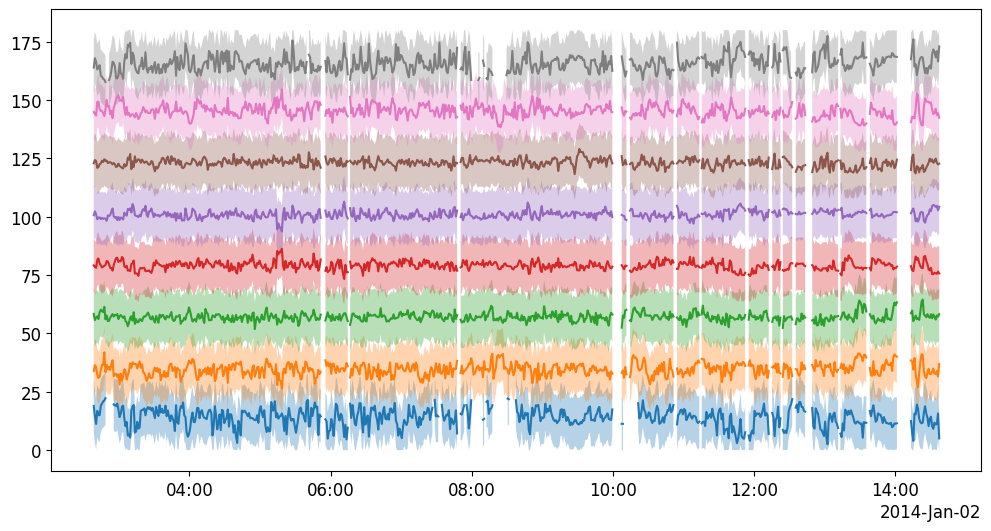

In [4]:
import matplotlib.pyplot as plt
def coverage_plot(cov):
    fig, ax = plt.subplots(figsize=(12, 6))

    for i, sect in enumerate(wind.sectors):
        plt.plot(cov.index, cov[(sect, "center")])
        plt.fill_between(cov.index, cov[(sect, "min")], cov[(sect, "max")], alpha=0.33)

coverage_plot(wind_cov)

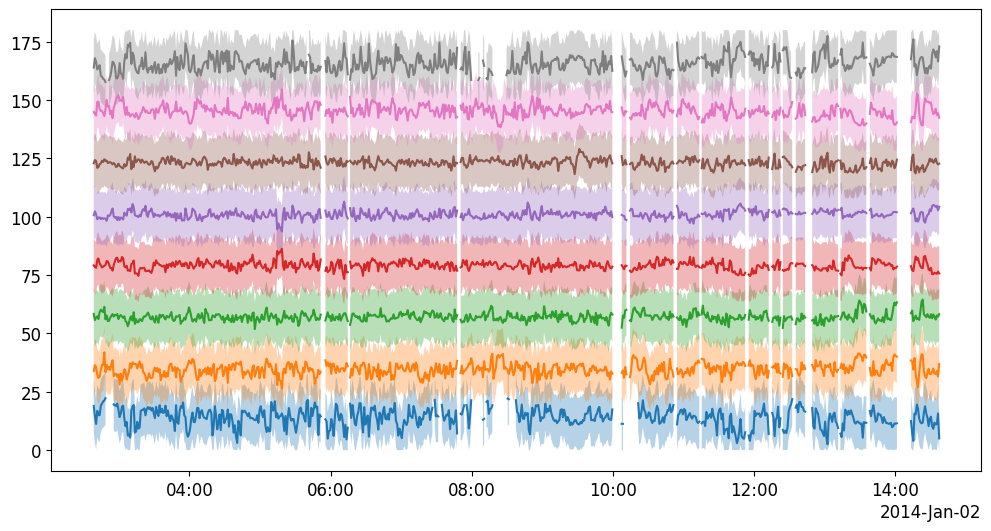

In [6]:
masked_cov, mask = induce_missingness(wind_cov, 0)
coverage_plot(masked_cov)

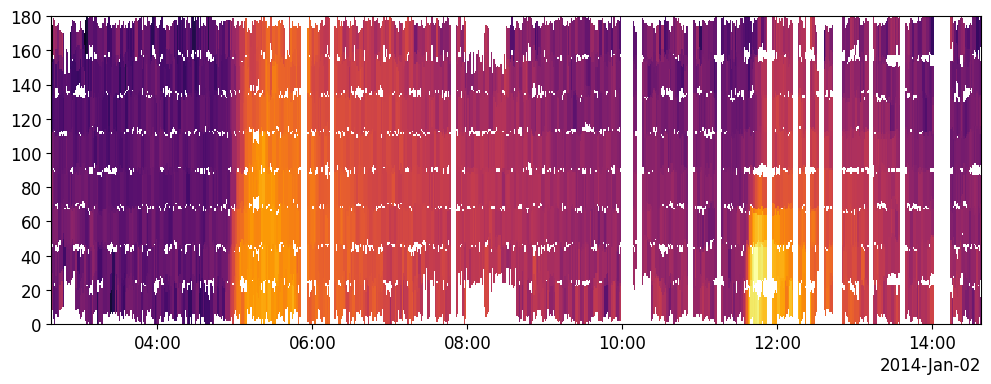

In [ ]:
X, Y, hist = pad_histogram(wind, wind_event.I_data, masked_cov, 180)
fig, ax = plt.subplots(figsize=(12,4))
norm = LogNorm(np.nanmin(hist), np.nanmax(hist))
plt.pcolormesh(X, Y, hist, cmap="inferno", norm=norm)

(<Figure size 800x500 with 5 Axes>,
 array([<Axes: title={'center': 'Wind'}>,
        <Axes: ylabel='Pitch angle [$\\degree$]'>,
        <Axes: xlabel='Universal Time (UT)', ylabel='Intensity\n [1/(s$\\,$cm²$\\,$sr$\\,$MeV)]'>],
       dtype=object))

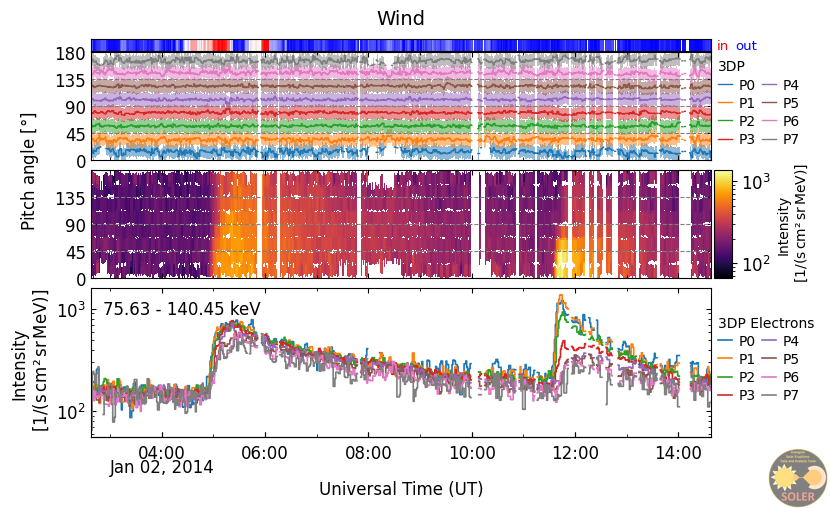

In [86]:
wind_event.overview_plot()

In [43]:
np.isnan(hist[:,1]).sum() == len(hist[:,0])

np.False_

(<Figure size 800x500 with 5 Axes>,
 array([<Axes: title={'center': 'Wind'}>,
        <Axes: ylabel='Pitch angle [$\\degree$]'>,
        <Axes: xlabel='Universal Time (UT)', ylabel='Intensity\n [1/(s$\\,$cm²$\\,$sr$\\,$MeV)]'>],
       dtype=object))

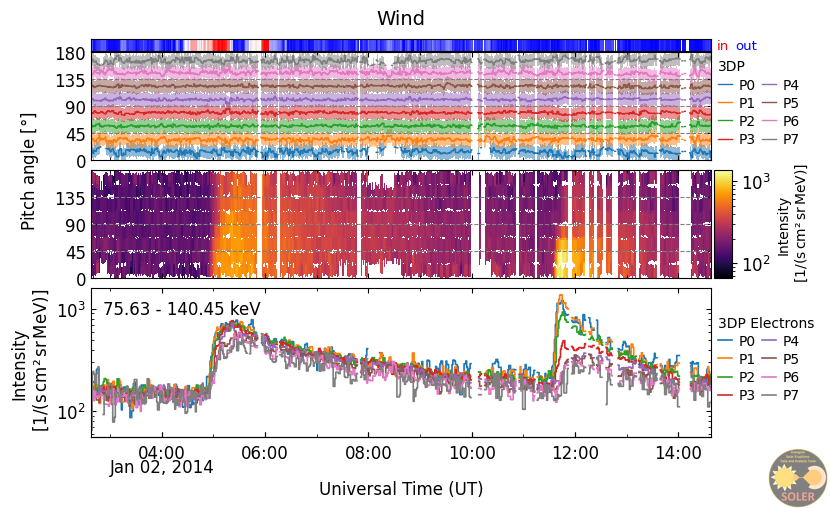

In [39]:
wind_event.overview_plot()

In [ ]:
p = 0.1
mask = np.random.choice([False, True], size=(cov.shape[0], cov.shape[1] // 3), p=[1-p, p])

In [51]:
data_filt = vectorized_filter(wind_event.I_data, np.median, size=(3,), axes=(0,))
wind_event.I_data = data_filt

(<Figure size 800x500 with 5 Axes>,
 array([<Axes: title={'center': 'Wind'}>,
        <Axes: ylabel='Pitch angle [$\\degree$]'>,
        <Axes: xlabel='Universal Time (UT)', ylabel='Intensity\n [1/(s$\\,$cm²$\\,$sr$\\,$MeV)]'>],
       dtype=object))

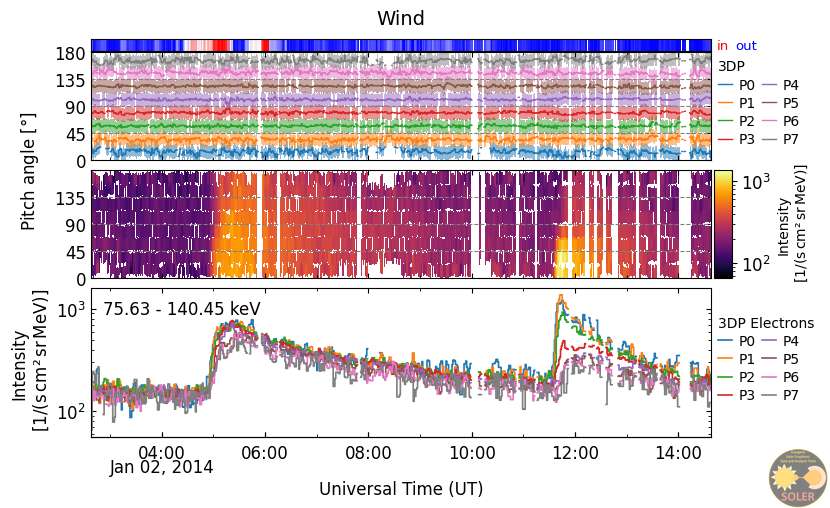

In [52]:
wind_event.overview_plot()

In [24]:
import numpy as np
bins = 8
bin_width_deg = 22.5
X, Y = np.meshgrid(np.arange(720), np.linspace(0 - bin_width_deg, (bins+1)*bin_width_deg, bins+3), indexing="ij")

In [25]:
Y

array([[-22.5,   0. ,  22.5, ..., 157.5, 180. , 202.5],
       [-22.5,   0. ,  22.5, ..., 157.5, 180. , 202.5],
       [-22.5,   0. ,  22.5, ..., 157.5, 180. , 202.5],
       ...,
       [-22.5,   0. ,  22.5, ..., 157.5, 180. , 202.5],
       [-22.5,   0. ,  22.5, ..., 157.5, 180. , 202.5],
       [-22.5,   0. ,  22.5, ..., 157.5, 180. , 202.5]], shape=(720, 11))

In [6]:
data = np.load("/home/ojsant/gradu/data/intensities/1min_1deg/Wind_20100518-100925_1min_1deg.npz")["full"]

In [ ]:
def convert_to_bool_coverage(cov, sc, bin_width_deg=22.5):
    directions = sc.sectors

    X, Y = np.meshgrid(cov.index.values,
                       np.linspace(0, 180, int(180 / bin_width_deg)),
                       indexing="ij")
    cov_arr = np.zeros_like(Y, dtype=np.bool_)  # zeros_like of bool type -> all False

    for direction in directions:
        # replace missing values with -1 to exclude from comparison in the loop
        dataf = cov[direction].mask(cov[direction].isna(), -1)
        for index, data in dataf.reset_index().iterrows():
            covered = np.ma.masked_inside(Y[index], data["min"], data["max"])
            cov_arr[index] = cov_arr[index] | covered.mask

    return X, Y, cov_arr


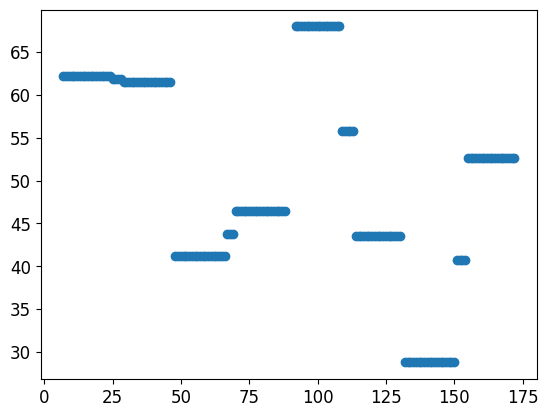

In [8]:
fig, axs = plt.subplots()

plt.scatter(np.arange(len(hist[100])), hist[100])

In [10]:
wind_event.coverage

P0                               P1             \
                              min     center        max        min     center   
Epoch                                                                           
2012-08-31 18:48:35.534  5.722113  16.972113  28.222113  19.201162  30.451162   
2012-08-31 18:49:35.534  4.443836  15.693836  26.943836  20.092354  31.342354   
2012-08-31 18:50:35.534  4.632547  15.882547  27.132547  19.948360  31.198360   
2012-08-31 18:51:35.534  4.652815  15.902815  27.152815  19.929544  31.179544   
2012-08-31 18:52:35.534  4.586166  15.836166  27.086166  19.976440  31.226440   
...                           ...        ...        ...        ...        ...   
2012-09-01 06:43:35.534  0.000000   6.685687  17.935686  23.917126  35.167126   
2012-09-01 06:44:35.534  0.000000   6.626003  17.876003  26.717308  37.967308   
2012-09-01 06:45:35.534  2.269046  13.519046  24.769047  28.859367  40.109367   
2012-09-01 06:46:35.534  2.205618  13.455618  24.705618  27.265594  38.515594   
2012-09-01 06:47:35.534  1.251603  12.501603  23.751602  26.554272  37.804272   

                                           P2                        \
                               max        min     center        max   
Epoch                                                                 
2012-08-31 18:48:35.534  41.701164  45.352013  56.602013  67.852013   
2012-08-31 18:49:35.534  42.592354  44.127033  55.377033  66.627029   
2012-08-31 18:50:35.534  42.448360  44.001942  55.251942  66.501938   
2012-08-31 18:51:35.534  42.429543  44.810883  56.060883  67.310883   
2012-08-31 18:52:35.534  42.476440  44.226971  55.476971  66.726974   
...                            ...        ...        ...        ...   
2012-09-01 06:43:35.534  46.417126  41.686134  52.936134  64.186134   
2012-09-01 06:44:35.534  49.217308  44.594452  55.844452  67.094452   
2012-09-01 06:45:35.534  51.359367  49.885406  61.135406  72.385406   
2012-09-01 06:46:35.534  49.765594  46.243084  57.493084  68.743088   
2012-09-01 06:47:35.534  49.054272  43.878822  55.128822  66.378822   

                                P3  ...          P4          P5              \
                               min  ...         max         min      center   
Epoch                               ...                                       
2012-08-31 18:48:35.534  67.944908  ...  111.430832  112.205101  123.455101   
2012-08-31 18:49:35.534  66.849716  ...  112.323372  113.353989  124.603989   
2012-08-31 18:50:35.534  67.326355  ...  112.683632  113.485886  124.735886   
2012-08-31 18:51:35.534  67.637924  ...  112.291672  112.730591  123.980591   
2012-08-31 18:52:35.534  67.338638  ...  112.600204  113.311462  124.561462   
...                            ...  ...         ...         ...         ...   
2012-09-01 06:43:35.534  67.369858  ...  113.311050  113.559448  124.809448   
2012-09-01 06:44:35.534  65.968971  ...  113.822670  118.382416  129.632416   
2012-09-01 06:45:35.534  66.145554  ...  113.193497  115.101669  126.351669   
2012-09-01 06:46:35.534  66.123436  ...  113.712677  115.153313  126.403313   
2012-09-01 06:47:35.534  65.908333  ...  114.328445  113.470863  124.720863   

                                             P6                          \
                                max         min      center         max   
Epoch                                                                     
2012-08-31 18:48:35.534  134.705109  136.020905  147.270905  158.520905   
2012-08-31 18:49:35.534  135.853989  134.510696  145.760696  157.010696   
2012-08-31 18:50:35.534  135.985886  134.307739  145.557739  156.807739   
2012-08-31 18:51:35.534  135.230591  134.742523  145.992523  157.242523   
2012-08-31 18:52:35.534  135.811462  134.557983  145.807983  157.057983   
...                             ...         ...         ...         ...   
2012-09-01 06:43:35.534  136.059448  131.950516  143.200516  154.450516   
2012-09-01 06:44:35.534  140.882416  130.593